In [10]:
%pip install numpy
%pip install pandas
%pip install matplotlib 
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%run data_preparation.py

/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/data_preparation.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _df = _df.groupby("traj_id", group_keys=False).apply(mark)


# Task 1.1

Most of it is in `data_preparation.py`. Below are the remaining parts.

#### Plot some example trajectories.

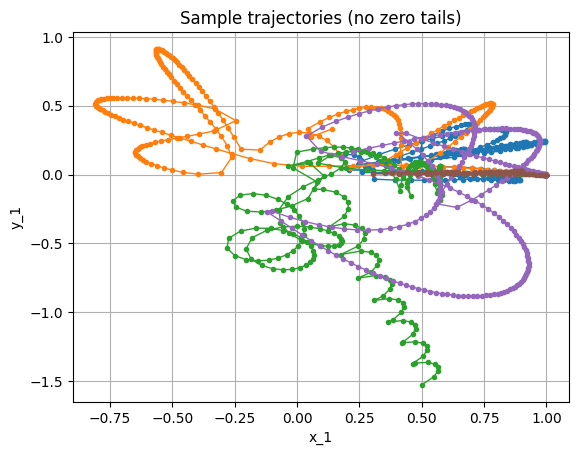

In [3]:
import matplotlib.pyplot as plt

sample_ids = df_clean["traj_id"].drop_duplicates().sample(6, random_state=42).tolist()

for tid in sample_ids:
    g = df_clean[(df_clean["traj_id"] == tid) & (~df_clean["zero_tail"])]
    plt.plot(g["x_1"].values, g["y_1"].values, marker=".", linewidth=1)
    
plt.xlabel("x_1"); plt.ylabel("y_1"); plt.title("Sample trajectories (no zero tails)")
plt.grid(True); plt.show()

# Task 1.2

### 1.2.1 Train model on training split

In [4]:
print(f"Train set: {X_train.shape[0]} samples, {X_train.shape[1]} features")

model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, y_train)


Train set: 15917 samples, 7 features


,steps,"[('standardscaler', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


### 1.2.2 Evaluation of the model with validation set

In [ ]:
# Make predictions
y_pred = model.predict(X_val)

# Calculate error
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")

Validation RMSE: 1.4006
Validation MAE: 0.8437


### 1.2.2.1 Evaluation of the model with cross validation

In [6]:
cross_validate(k_fold_data, model, n_splits=5)

Fold 1/5 - RMSE: 1.8888, MAE: 1.0374
Fold 2/5 - RMSE: 1.5613, MAE: 0.8800
Fold 3/5 - RMSE: 1.5640, MAE: 0.8622
Fold 4/5 - RMSE: 1.0764, MAE: 0.7468
Fold 5/5 - RMSE: 1.4184, MAE: 0.7844

Cross-Validation Results:
RMSE: 1.5018 ± 0.2627
MAE: 0.8622 ± 0.1004


{'rmse_mean': np.float64(1.5017959944251227),
 'rmse_std': np.float64(0.26272746829313703),
 'mae_mean': np.float64(0.8621518372006145),
 'mae_std': np.float64(0.10039235927954245),
 'rmse_scores': [np.float64(1.8888237132956587),
  np.float64(1.5613492310656463),
  np.float64(1.5640264162828132),
  np.float64(1.0764013652568887),
  np.float64(1.4183792462246065)],
 'mae_scores': [1.037431435956873,
  0.8799572396618558,
  0.8621796899769606,
  0.7467955305897084,
  0.7843952898176747]}

### 1.2.3 Plot the results

In [7]:
def plot_y_yhat(y_test, y_pred, plot_title="plot"):
    labels = ['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3']
    MAX = 500  # Maximum points to plot
    
    # Sample points if dataset is too large
    if len(y_test) > MAX:
        idx = np.random.choice(len(y_test), MAX, replace=False)
    else:
        idx = np.arange(len(y_test))
    
    plt.figure(figsize=(10, 10))
    
    for i in range(6):
        # min/max for diagonal line
        x0 = np.min(y_test[idx, i])
        x1 = np.max(y_test[idx, i])
        
        plt.subplot(3, 2, i + 1)
        
        # Scatter plot: predicted vs actual
        plt.scatter(y_test[idx, i], y_pred[idx, i], alpha=0.6, s=20)
        
        # Perfect prediction line (diagonal)
        plt.plot([x0, x1], [x0, x1], color='red', linewidth=2, label='Perfect prediction')
        
        plt.xlabel('True ' + labels[i])
        plt.ylabel('Predicted ' + labels[i])
        plt.title(labels[i])
        plt.grid(True, alpha=0.3)
        plt.axis('square')  # Equal aspect ratio
    
    plt.tight_layout()
    plt.savefig(f'results/{plot_title}.png', dpi=150)
    plt.show()
    
    print(f"Saved: results/{plot_title}.pdf and .png")


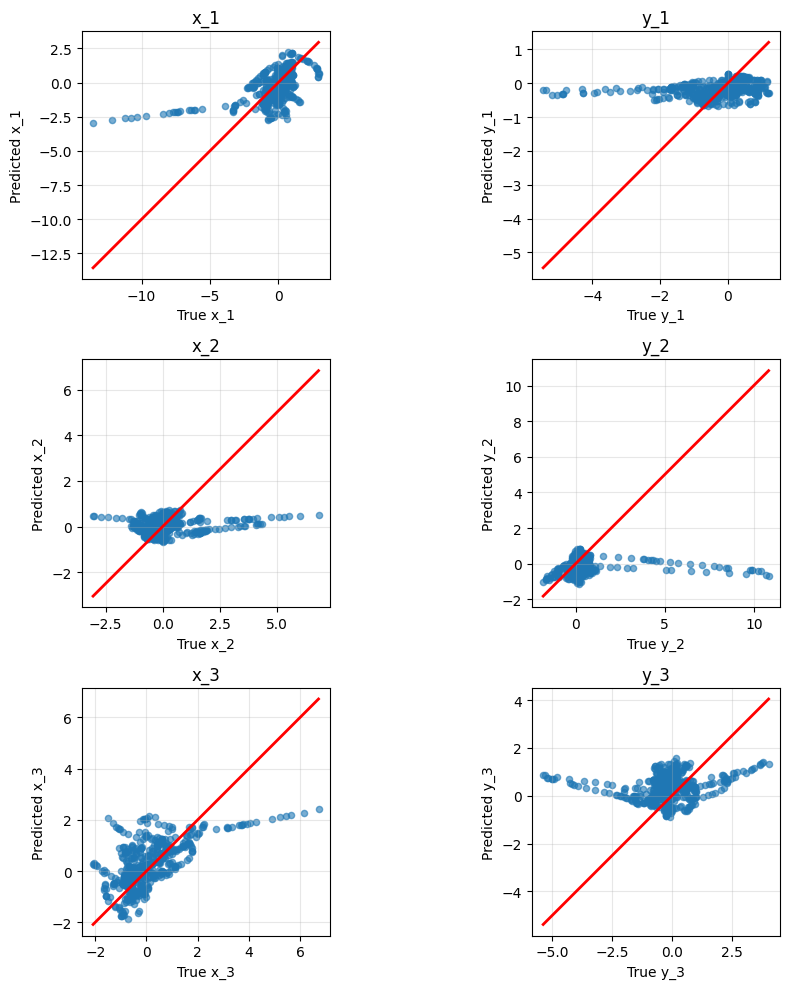

Saved: results/validation_y_yhat.pdf and .png


In [8]:
plot_y_yhat(y_val, y_pred, plot_title="validation_y_yhat")

### 1.2.4 Create submission

#### Predict on test set

In [ ]:
# y_pred = model.predict(X_test)

# pred_df = export_predictions_to_csv(y_pred, RESULTS_DIR / "baseline-model.csv")

Predictions saved to: results/baseline-model.csv
Shape: (1041621, 7)
First few rows:
   Id       x_1       y_1       x_2       y_2       x_3       y_3
0   0  0.545418 -0.222711 -0.348496  0.350496 -0.196922 -0.127786
1   1  0.537778 -0.223849 -0.346702  0.346305 -0.191076 -0.122456
2   2  0.530139 -0.224988 -0.344909  0.342114 -0.185231 -0.117126
3   3  0.522500 -0.226126 -0.343115  0.337922 -0.179385 -0.111796
4   4  0.514861 -0.227265 -0.341322  0.333731 -0.173539 -0.106466
